# Visualizations for Mixed Radiometric Data with RFI

This notebook visualizes synthetic radiometric data mixed with RFI signals. It includes plots for TB spectra, time series, and RFI impact comparison.

In [12]:
# Import Required Libraries
import sys
sys.path.append('/Users/jorgeandres/Code/PYTHON/RFIGenerator')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.models.radiometry import generate_synthetic_dataset
from src.models.signal_mixer import generate_rfi_sources, mix_signals

## Generate Synthetic Radiometric Data

In [13]:
# Generate synthetic data
data = generate_synthetic_dataset(n_dataframes=1, noise_std=2.0, seed=42)
df_original = data[0] if isinstance(data, list) else data
print("Original data shape:", df_original.shape)
df_original.head()

Original data shape: (40, 30)


,Record,Date/Time,50,Az(deg),El(deg),TkBB(K),Ch 22.000,Ch 22.348,Ch 22.696,Ch 23.043,...,Ch 26.870,Ch 27.217,Ch 27.565,Ch 27.913,Ch 28.261,Ch 28.609,Ch 28.957,Ch 29.304,Ch 29.652,Ch 30.000
0,2,04/04/23 00:05:05,50,0.0,19.8,306.907385,183.476999,183.816196,178.155938,182.339892,...,170.268390,171.734893,165.401461,169.819180,166.880263,161.593500,168.293543,162.485240,174.497656,166.361587
1,3,04/04/23 00:05:23,50,45.0,90.0,306.906842,179.032150,179.710748,179.769904,172.567838,...,177.926562,162.069167,174.155536,159.295604,155.520456,163.811781,159.751943,164.836699,157.938693,154.590895
2,4,04/04/23 00:05:41,50,90.0,160.2,306.909100,184.533820,179.847570,186.945717,185.700653,...,173.477088,172.599928,166.084377,163.890167,158.902276,177.574061,164.384677,157.420897,159.717745,161.960225
3,5,04/04/23 00:05:59,50,135.0,19.8,306.912374,190.661209,180.670976,178.715578,173.428109,...,169.242029,176.780771,161.617301,170.710324,171.110206,166.044021,163.343379,166.697239,169.136429,159.545456
4,6,04/04/23 00:06:17,50,0.0,90.0,306.905728,178.360926,171.269518,173.750095,179.857283,...,173.363850,168.555390,164.389934,158.638446,164.733847,168.756321,159.967908,162.103085,163.810716,165.506926


## Generate RFI Sources and Mix Signals

In [14]:
# Generate RFI sources
rng = np.random.default_rng(42)
sources = generate_rfi_sources(n_sources=3, source_classes=["satellite", "aircraft"], rng=rng)

# Adjust RFI parameters for visibility
for source in sources:
    source['avg_power_K'] *= 20  # Increase power
    source['peak_power_K'] *= 20
    source['sigma_deg'] = 30.0  # Larger beamwidth for higher coupling
    source['az_deg'] = rng.uniform(-5, 5)  # Closer in azimuth
    source['el_deg'] = rng.uniform(15, 25)  # Closer in elevation

print(f"Generated {len(sources)} RFI sources")

# Mix signals
df_mixed, rfi_infos = mix_signals(df_original, sources, rng)
print("RFI mixing completed")
print("RFI infos:", rfi_infos)

Generated 3 RFI sources
RFI mixing completed
RFI infos: [[{'center_ghz': 25.51102751801642, 'bandwidth_ghz': 1.2949669838715046, 'power': 275.3418783101196, 'avg_coupling': np.float64(0.12834719903974806)}, {'center_ghz': 25.603087503164538, 'bandwidth_ghz': 0.5876571351372428, 'power': 715.0920960645317, 'avg_coupling': np.float64(0.12773420918378675)}, {'center_ghz': 28.621049375940657, 'bandwidth_ghz': 0.965913378726994, 'power': 483.6207745038947, 'avg_coupling': np.float64(0.13698235453400343)}]]


## Visualize TB Spectra

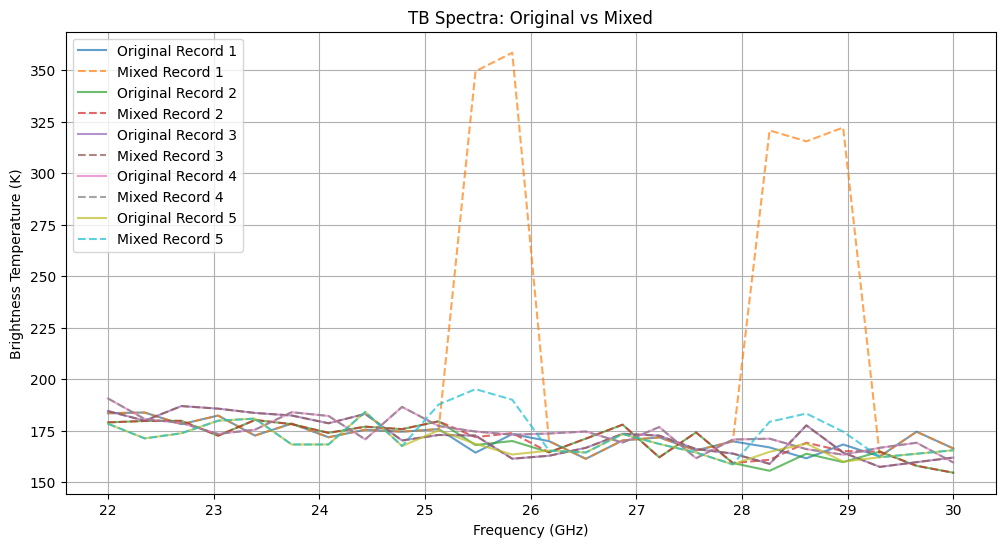

In [19]:
# Extract frequency columns
freq_cols = [col for col in df_original.columns if col.startswith("Ch ")]
freqs = [float(col.split()[1]) for col in freq_cols]

# Plot spectra for first few records
plt.figure(figsize=(12, 6))
for i in range(min(5, len(df_original))):
    plt.plot(freqs, df_original.iloc[i][freq_cols], label=f'Original Record {i+1}', alpha=0.7)
    plt.plot(freqs, df_mixed.iloc[i][freq_cols], label=f'Mixed Record {i+1}', linestyle='--', alpha=0.7)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('TB Spectra: Original vs Mixed')
plt.legend()
plt.grid(True)
plt.show()

## Time Series at a Specific Frequency

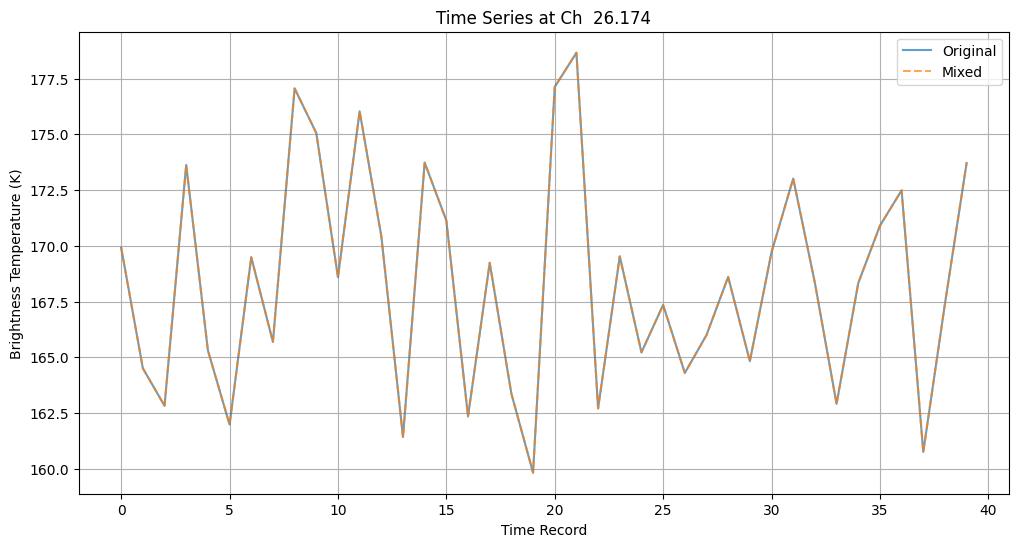

In [20]:
# Choose a frequency channel, e.g., middle one
mid_freq = freq_cols[len(freq_cols)//2]

plt.figure(figsize=(12, 6))
plt.plot(df_original.index, df_original[mid_freq], label='Original', alpha=0.7)
plt.plot(df_mixed.index, df_mixed[mid_freq], label='Mixed', linestyle='--', alpha=0.7)
plt.xlabel('Time Record')
plt.ylabel('Brightness Temperature (K)')
plt.title(f'Time Series at {mid_freq}')
plt.legend()
plt.grid(True)
plt.show()

## Visualize RFI Impact

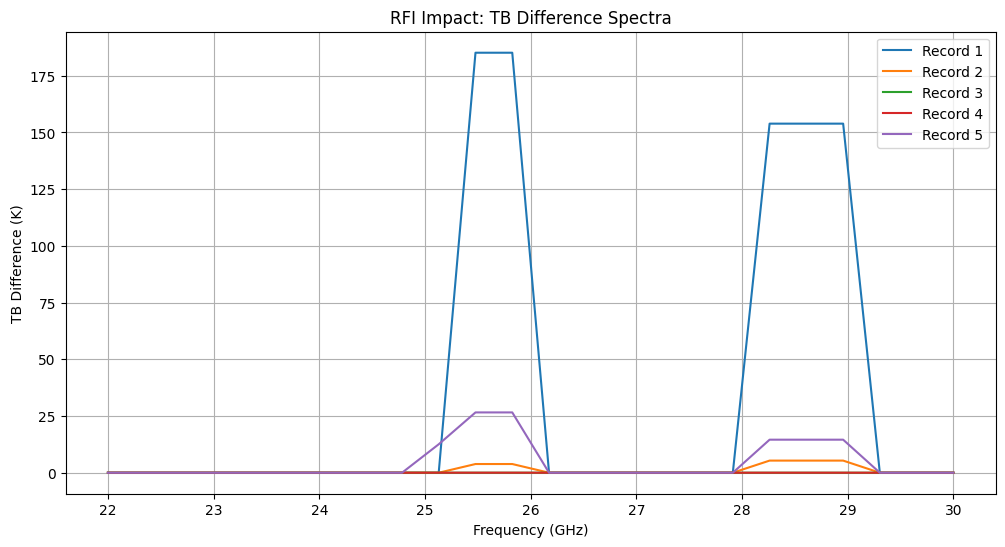

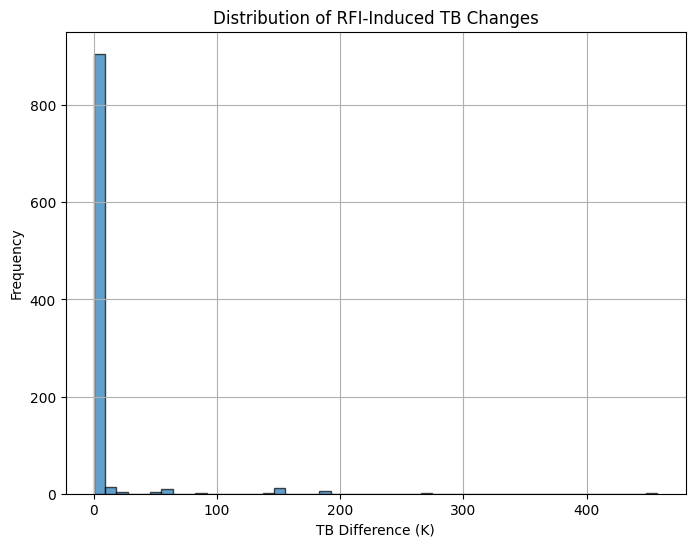

In [21]:
# Compute difference
df_diff = df_mixed[freq_cols] - df_original[freq_cols]

# Plot difference spectra
plt.figure(figsize=(12, 6))
for i in range(min(5, len(df_diff))):
    plt.plot(freqs, df_diff.iloc[i], label=f'Record {i+1}')
plt.xlabel('Frequency (GHz)')
plt.ylabel('TB Difference (K)')
plt.title('RFI Impact: TB Difference Spectra')
plt.legend()
plt.grid(True)
plt.show()

# Histogram of differences
plt.figure(figsize=(8, 6))
plt.hist(df_diff.values.flatten(), bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('TB Difference (K)')
plt.ylabel('Frequency')
plt.title('Distribution of RFI-Induced TB Changes')
plt.grid(True)
plt.show()

## Summary

In [22]:
print("Visualization complete. The notebook shows the impact of RFI on radiometric data.")
print(f"Total RFI sources: {len(sources)}")
for i, info in enumerate(rfi_infos):
    print(f"Source {i+1}: Center {info['center_ghz']:.2f} GHz, Bandwidth {info['bandwidth_ghz']:.2f} GHz, Avg Coupling {info['avg_coupling']:.3f}")

Visualization complete. The notebook shows the impact of RFI on radiometric data.
Total RFI sources: 3


TypeError: list indices must be integers or slices, not str